# Scary Stochastics, Week 1: Markov Chains
## Notebook 3 of 3 — Simulating Forward

This notebook is also self-contained: it regenerates the same harvest data and calibrated transition matrix as Notebooks 1–2, then uses that matrix to simulate many possible futures — the payoff of the calibrate-then-simulate approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Harvest / Halloween color palette
HARVEST = {
    "poor":    "#3B2145",  # deep purple  - a rough year
    "average": "#B5451B",  # burnt orange/rust
    "good":    "#E8741C",  # pumpkin orange
    "bumper":  "#D9A404",  # golden mustard - the best years
    "black":   "#1B1B1B",
    "cream":   "#FBF3E1",
}

CATS = ["Poor", "Average", "Good", "Bumper"]
CAT_COLORS = [HARVEST["poor"], HARVEST["average"], HARVEST["good"], HARVEST["bumper"]]

plt.rcParams.update({
    "figure.facecolor": HARVEST["cream"],
    "axes.facecolor": HARVEST["cream"],
    "axes.edgecolor": HARVEST["black"],
    "text.color": HARVEST["black"],
    "axes.labelcolor": HARVEST["black"],
    "xtick.color": HARVEST["black"],
    "ytick.color": HARVEST["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

### Rebuild the calibrated transition matrix

In [2]:
# Synthetic 10-year pumpkin harvest (tons/acre)
years = np.arange(2016, 2026)
base_yield = 15
yields_ = base_yield + np.random.normal(0, 4, size=10)
yields_ = np.clip(yields_, 3, None).round(1)

harvest_df = pd.DataFrame({"Year": years, "Yield_tons_per_acre": yields_})
harvest_df["Category"] = pd.qcut(harvest_df["Yield_tons_per_acre"], q=4, labels=CATS)
harvest_df

sequence = harvest_df["Category"].tolist()
raw_counts = pd.DataFrame(0, index=CATS, columns=CATS)
for a, b in zip(sequence[:-1], sequence[1:]):
    raw_counts.loc[a, b] += 1

smoothed = raw_counts + 1
transition_matrix = smoothed.div(smoothed.sum(axis=1), axis=0)
transition_matrix

,Poor,Average,Good,Bumper
Poor,0.285714,0.142857,0.285714,0.285714
Average,0.166667,0.333333,0.333333,0.166667
Good,0.200000,0.200000,0.200000,0.400000
Bumper,0.428571,0.142857,0.142857,0.285714


### Simulate one 100-year path

In [3]:
np.random.seed(7)
N_YEARS = 100

state = "Average"
path = [state]
for _ in range(N_YEARS - 1):
    probs = transition_matrix.loc[state].values
    state = np.random.choice(CATS, p=probs)
    path.append(state)

path_idx = [CATS.index(s) for s in path]

### Visual 5 — A simulated century

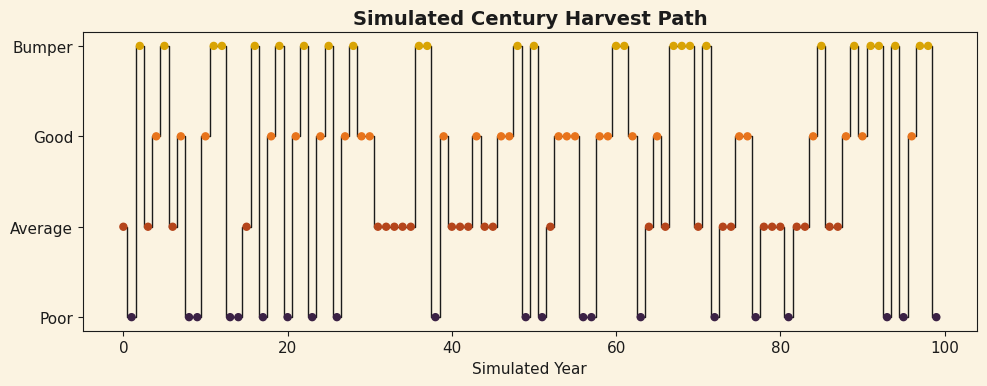

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.step(range(N_YEARS), path_idx, color=HARVEST["black"], where="mid", linewidth=1)
ax.scatter(range(N_YEARS), path_idx, c=[CAT_COLORS[i] for i in path_idx], zorder=3, s=25)
ax.set_yticks(range(4)); ax.set_yticklabels(CATS)
ax.set_xlabel("Simulated Year")
ax.set_title("Simulated Century Harvest Path")
plt.tight_layout()
plt.savefig("05_simulated_path.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Run 1,000 simulated centuries

How bad can a bad stretch get? For each simulated 100-year run, we track the longest streak of consecutive "Poor" years.

In [5]:
def longest_streak(seq, target):
    best = cur = 0
    for s in seq:
        cur = cur + 1 if s == target else 0
        best = max(best, cur)
    return best

N_SIMS = 1000
streaks = []
for _ in range(N_SIMS):
    state = "Average"
    seq = [state]
    for _ in range(N_YEARS - 1):
        probs = transition_matrix.loc[state].values
        state = np.random.choice(CATS, p=probs)
        seq.append(state)
    streaks.append(longest_streak(seq, "Poor"))

### Visual 6 — Longest poor-harvest streaks

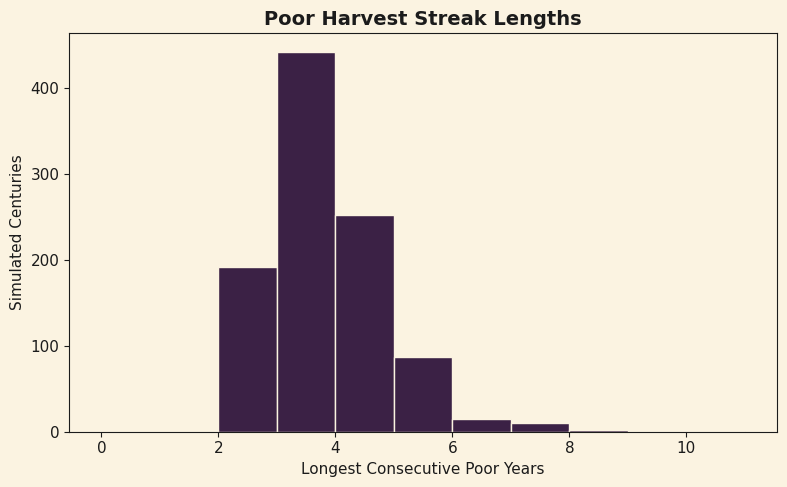

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(streaks, bins=range(0, max(streaks) + 2),
        color=HARVEST["poor"], edgecolor=HARVEST["cream"])
ax.set_title("Poor Harvest Streak Lengths")
ax.set_xlabel("Longest Consecutive Poor Years")
ax.set_ylabel("Simulated Centuries")
plt.tight_layout()
plt.savefig("06_poor_streaks.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Where do the odds settle?

Starting from a flat guess (25% each state), repeatedly applying the transition matrix shows how the long-run odds of each harvest category converge.

In [7]:
dist = np.array([0.25, 0.25, 0.25, 0.25])
history = [dist]
T = transition_matrix.values
for _ in range(20):
    dist = dist @ T
    history.append(dist)
history = np.array(history)

### Visual 7 — Long-run convergence

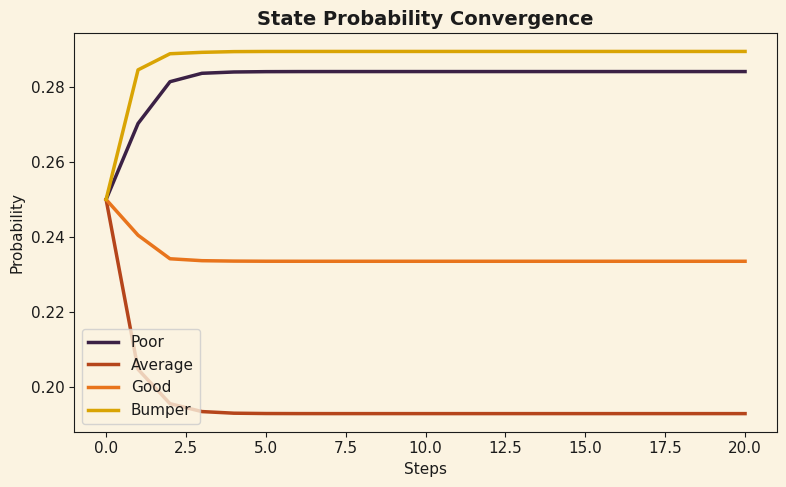

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, cat in enumerate(CATS):
    ax.plot(history[:, i], label=cat, color=CAT_COLORS[i], linewidth=2.5)
ax.set_title("State Probability Convergence")
ax.set_xlabel("Steps")
ax.set_ylabel("Probability")
ax.legend()
plt.tight_layout()
plt.savefig("07_convergence.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Up next

Week 2 picks up the thread with Poisson Processes, modeling trick-or-treater arrivals as a queueing problem.